In [ ]:
#| default_exp activations

# Activation stats

In [ ]:
# import sys
# sys.path.insert(0, '/app/data/deeplearning/course22p2_zh/')

In [ ]:
import sys
sys.path.insert(0, '/home/tzyy/projects/course22p2_zh/')

In [ ]:
#|export
from __future__ import annotations
import random,math,torch,numpy as np,matplotlib.pyplot as plt
import fastcore.all as fc
from functools import partial

from miniai.datasets import *
from miniai.learner import *

In [ ]:
import torch.nn.functional as F,matplotlib as mpl
from pathlib import Path
from operator import attrgetter,itemgetter
from contextlib import contextmanager

from torch import tensor,nn,optim
import torchvision.transforms.functional as TF
from datasets import load_dataset

from fastcore.test import test_close

torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
mpl.rcParams['figure.constrained_layout.use'] = True

import logging
logging.disable(logging.WARNING)

In [ ]:
#|export
def set_seed(seed, deterministic=False):
    torch.use_deterministic_algorithms(deterministic)
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [ ]:
x,y = 'image','label'
name = "fashion_mnist"
dsd = load_dataset(name)
bs = 1024

@inplace
def transformi(b): b[x] = [TF.to_tensor(o) for o in b[x]]

tds = dsd.with_transform(transformi)
dls = DataLoaders.from_dd(tds, bs, num_workers=4)
dt = dls.train

## Baseline

In [ ]:
def conv(ni, nf, ks=3, act=True):
    res = nn.Conv2d(ni, nf, stride=2, kernel_size=ks, padding=ks//2)
    if act: res = nn.Sequential(res, nn.ReLU())
    return res

def cnn_layers():
    return [
        conv(1 ,8, ks=5),        #14x14
        conv(8 ,16),             #7x7
        conv(16,32),             #4x4
        conv(32,64),             #2x2
        conv(64,10, act=False),  #1x1
        nn.Flatten()]

We want to train quickly, so that means training at a high learning rate.

In [ ]:
from torcheval.metrics import MulticlassAccuracy

In [ ]:
metrics = MetricsCB(accuracy=MulticlassAccuracy())
cbs = [TrainCB(), DeviceCB(), metrics, ProgressCB(plot=False)]

In [ ]:
def fit(model, epochs=1, xtra_cbs=None):
    learn = Learner(model, dls, loss_func=F.cross_entropy, lr=0.6, cbs=cbs+fc.L(xtra_cbs))
    learn.fit(epochs)
    return learn

In [ ]:
set_seed(1)
learn = fit(nn.Sequential(*cnn_layers()))

HTML(
<style>
    progress { appearance: none; border: none; border-radius: 4px; width: 300px;
        height: 20px; vertical-align: middle; background: #e0e0e0; }

    progress::-webkit-progress-bar { background: #e0e0e0; border-radius: 4px; }
    progress::-webkit-progress-value { background: #2196F3; border-radius: 4px; }
    progress::-moz-progress-bar { background: #2196F3; border-radius: 4px; }

    progress:not([value]) {
        background: repeating-linear-gradient(45deg, #7e7e7e, #7e7e7e 10px, #5c5c5c 10px, #5c5c5c 20px); }

    progress.progress-bar-interrupted::-webkit-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-value { background: #F44336; }
    progress.progress-bar-interrupted::-webkit-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted::-moz-progress-bar { background: #F44336; }
    progress.progress-bar-interrupted { background: #F44336; }    

    table.fastprogress { border-collapse: collapse; margin: 1em 0; font-size: 0.9em; }
    table.fastprogress th, table.fastprogress td { padding: 8px 12px; border: 1px solid #ddd; text-align: left; }
    table.fastprogress thead tr { background: #f8f9fa; font-weight: bold; }
    table.fastprogress tbody tr:nth-of-type(even) { background: #f8f9fa; }
</style>
)

accuracy,loss,epoch,train
0.157,2.300,0,train
0.266,2.084,0,eval


## Hooks

### Manual insertion

In [ ]:
class SequentialModel(nn.Module):
    def __init__(self, *layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)
        self.act_means = [[] for _ in layers]
        self.act_stds  = [[] for _ in layers]
        
    def __call__(self, x):
        for i,l in enumerate(self.layers):
            x = l(x)
            self.act_means[i].append(to_cpu(x).mean())
            self.act_stds [i].append(to_cpu(x).std ())
        return x
    
    def __iter__(self): return iter(self.layers)

In [ ]:
set_seed(1)
model = SequentialModel(*cnn_layers())
learn = fit(model)

accuracy,loss,epoch,train
0.163,2.298,0,train
0.202,2.035,0,eval


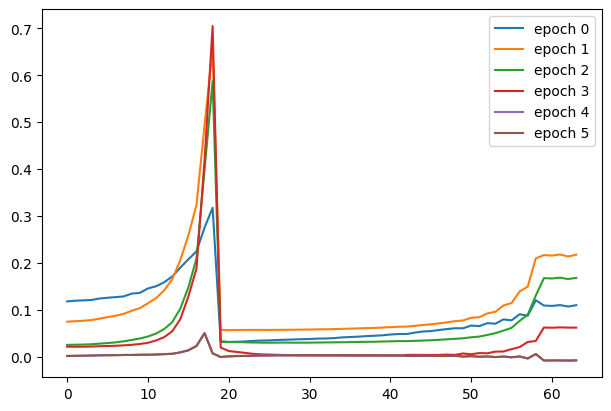

In [ ]:
plt.figure(figsize=(6, 4))
for i, l in enumerate(model.act_means): plt.plot(l, label=f'epoch {i}')
plt.legend();

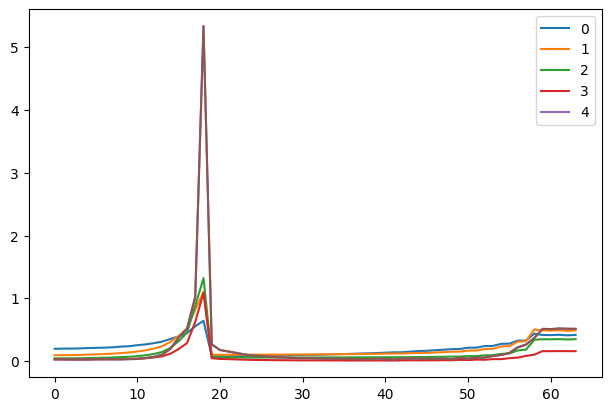

In [ ]:
plt.figure(figsize=(6, 4))
for l in model.act_stds: plt.plot(l)
plt.legend(range(5));

### Pytorch hooks

Hooks are PyTorch object you can add to any nn.Module. A hook will be called when a layer, it is registered to, is executed during the forward pass (forward hook) or the backward pass (backward hook). Hooks don't require us to rewrite the model.

运用搜索，给我pytorch hook的文档链接地址

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

PyTorch hooks 相关的官方文档链接如下：

### 主要文档页面

**`nn.Module` hooks** — 注册到层（module）上的钩子：
- [**`register_forward_hook(hook)`**](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook) — 前向传播时触发
- [**`register_forward_pre_hook(hook)`**](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_pre_hook) — 前向传播前触发
- [**`register_full_backward_hook(hook)`**](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook) — 反向传播时触发（推荐用这个，而非旧的 `register_backward_hook`）

**Tensor hooks** — 注册到张量上的钩子：
- [**`Tensor.register_hook(hook)`**](https://pytorch.org/docs/stable/generated/torch.Tensor.register_hook.html) — 当张量的梯度被计算时触发

另外，PyTorch 官方还有一个关于 hooks 的教程笔记：
- [**Hooks for torch.nn modules**](https://pytorch.org/docs/stable/notes/modules.html#hooks)

你想看看哪个的用法示例？还是需要我直接结合你上面的代码（激活值统计）来演示怎么用 hook 来实现同样的事情？

<details class='token-usage-details' markdown='1'><summary>$0.0002</summary>

`total=10,921 | in=10,448 | out=473 | cached=99.2% | reasoning=134 | searches=0 | $0.0002`

</details>


register_forward_hook(hook, *, prepend=False, with_kwargs=False, always_call=False)[source]

prepend参数的作用是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`prepend` 控制这个 hook **插入到已有 hook 链的哪个位置**。

- **`prepend=False`（默认）**：新注册的 hook **追加**到已有 hook 列表的末尾，也就是按注册顺序最后执行。
- **`prepend=True`**：新注册的 hook **插入**到已有 hook 列表的开头，也就是比之前注册的所有 hook 都先执行。

### 什么时候有用？

当同一个模块上注册了多个 forward hook，而你希望**某个 hook 在其他 hook 之前执行**（比如先做预处理再交给其他 hook），就可以用 `prepend=True`。

简单来说，`prepend=False` 是"后来者居尾"，`prepend=True` 是"后来者居上"。

想看看一个实际例子来感受区别吗？

<details class='token-usage-details' markdown='1'><summary>$0.0003</summary>

`total=11,155 | in=10,873 | out=282 | cached=94.2% | reasoning=107 | searches=0 | $0.0003`

</details>


<table>
  <thead>
    <tr>
      <th>方法</th>
      <th>触发时机</th>
      <th>签名</th>
      <th>能否修改输出/输入</th>
      <th>说明</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>register_buffer</code></td>
      <td>—（非 hook）</td>
      <td><code>(name, tensor, persistent=True)</code></td>
      <td>—</td>
      <td>注册一个<strong>非参数</strong>的张量（如 BatchNorm 的 <code>running_mean</code>）。<br>
        <code>persistent=True</code>：随 <code>state_dict</code> 保存 / 加载；<br>
        <code>persistent=False</code>：不保存，仅存在于内存。</td>
    </tr>
    <tr>
      <td><code>register_forward_hook</code></td>
      <td><code>forward()</code> 计算完 <strong>之后</strong></td>
      <td><code>hook(module, args, output) → None | modified output</code></td>
      <td>✅ 可修改 <code>output</code>（不能修改输入影响 forward）</td>
      <td>最常用的 hook。可选 <code>with_kwargs=True</code> 接收关键字参数；<br>
        <code>always_call=True</code> 即使在 forward 抛出异常时也执行。</td>
    </tr>
    <tr>
      <td><code>register_forward_pre_hook</code></td>
      <td><code>forward()</code> 被调用 <strong>之前</strong></td>
      <td><code>hook(module, args) → None | modified args</code></td>
      <td>✅ 可修改 <code>args</code>（从而影响 forward 的输入）</td>
      <td>适合做输入预处理（如把数据从 CPU 搬到 GPU）。</td>
    </tr>
    <tr>
      <td><code>register_full_backward_hook</code></td>
      <td>该模块的梯度被计算 <strong>之后</strong></td>
      <td><code>hook(module, grad_input, grad_output) → tuple(Tensor) | None</code></td>
      <td>✅ 可返回新的 <code>grad_input</code> 替代原梯度</td>
      <td><strong>不允许 inplace 修改</strong>输入输出。<br>
        <code>grad_input</code> / <code>grad_output</code> 是对应输入/输出张量的梯度。</td>
    </tr>
    <tr>
      <td><code>register_full_backward_pre_hook</code></td>
      <td>该模块的梯度被计算 <strong>之前</strong></td>
      <td><code>hook(module, grad_output) → tuple[Tensor, ...] | Tensor | None</code></td>
      <td>✅ 可返回新的 <code>grad_output</code> 替代原梯度</td>
      <td>与 <code>full_backward_hook</code> 相反，它在梯度<strong>计算之前</strong>截获 <code>grad_output</code>，<br>
        适合做梯度裁剪或修改。</td>
    </tr>
  </tbody>
</table>

In [ ]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

In [ ]:
model

Sequential(
  (0): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
  )
  (1): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (4): Conv2d(64, 10, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (5): Flatten(start_dim=1, end_dim=-1)
)


A hook is attached to a layer, and needs to have a function that takes three arguments: module, input, output. Here we store the mean and std of the output in the correct position of our list.

In [ ]:
act_means = [[] for _ in model]
act_stds  = [[] for _ in model]

In [ ]:
def append_stats(i, mod, inp, outp):
    # import pdb;pdb.set_trace()
    act_means[i].append(to_cpu(outp).mean())
    act_stds [i].append(to_cpu(outp).std())

In [ ]:
for i,m in enumerate(model): m.register_forward_hook(partial(append_stats, i))

In [ ]:
fit(model)

accuracy,loss,epoch,train
0.161,2.297,0,train
0.100,2.194,0,eval


In [ ]:
len(act_means[0])

64


为什么len(act_means[0])==64

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

每次模型做 forward pass，hook 就会被触发一次，所以 `act_means[0]` 会追加一个值。

`fit(model)` 跑了 1 个 epoch，包括：
- **训练阶段**：遍历训练集的所有 batch
- **验证阶段**：遍历验证集的所有 batch

两个阶段的 batch 数加起来就是 64。

你可以验证一下：

```python
print(len(dls.train), len(dls.valid))
```

看看两个数加起来是不是正好等于 64？

<details class='token-usage-details' markdown='1'><summary>$0.1324</summary>

`total=18,535 | in=16,464 | out=2,071 | cached=0.0% | cache_new=10,447 | reasoning=919 | searches=0 | $0.1324`

</details>


In [ ]:
print(len(dls.train), len(dls.valid))

59 5


batch_size不是1024吗，总大小是60000+10000

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

对，59 + 5 = 64，完全吻合！✓

但注意验证集是 10000 条数据，按 bs=1024 应该是 10 个 batch，为什么只有 5 个？

你可以猜猜看：`DataLoaders.from_dd` 对验证集用的 batch size 是多少？

<details class='token-usage-details' markdown='1'><summary>$0.0551</summary>

`total=17,454 | in=16,783 | out=671 | cached=62.2% | cache_new=6,032 | reasoning=234 | searches=0 | $0.0551`

</details>


哪里设置的bs

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

回头看看这行代码：

```python
dls = DataLoaders.from_dd(tds, bs, num_workers=4)
```

只传了一个 `bs=1024`。那验证集的 batch size 是从哪来的呢？

你可以直接检查一下：

```python
dls.valid.batch_size
```

看看输出是多少？

<details class='token-usage-details' markdown='1'><summary>$0.0156</summary>

`total=17,205 | in=16,946 | out=259 | cached=97.2% | cache_new=246 | reasoning=125 | searches=0 | $0.0156`

</details>


In [ ]:
dls.valid.batch_size

2048


In [ ]:
DataLoaders.from_dd??


````python
@classmethod
def from_dd(cls, dd, batch_size, as_tuple=True, **kwargs):
    f = collate_dict(dd['train'])
    return cls(*get_dls(*dd.values(), bs=batch_size, collate_fn=f, **kwargs))
````

**File:** `~/deeplearning/course22p2_zh/miniai/datasets.py`

哪里设置的2048

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

继续挖！看看 `get_dls` 的源码：

```python
get_dls??
```

<details class='token-usage-details' markdown='1'><summary>$0.0135</summary>

`total=17,468 | in=17,335 | out=133 | cached=96.5% | cache_new=169 | reasoning=77 | searches=0 | $0.0135`

</details>


In [ ]:
from miniai.datasets import get_dls
get_dls??


````python
def get_dls(train_ds, valid_ds, bs, **kwargs):
    return (DataLoader(train_ds, batch_size=bs, shuffle=True, **kwargs),
            DataLoader(valid_ds, batch_size=bs*2, **kwargs))
````

**File:** `~/deeplearning/course22p2_zh/miniai/training.py`

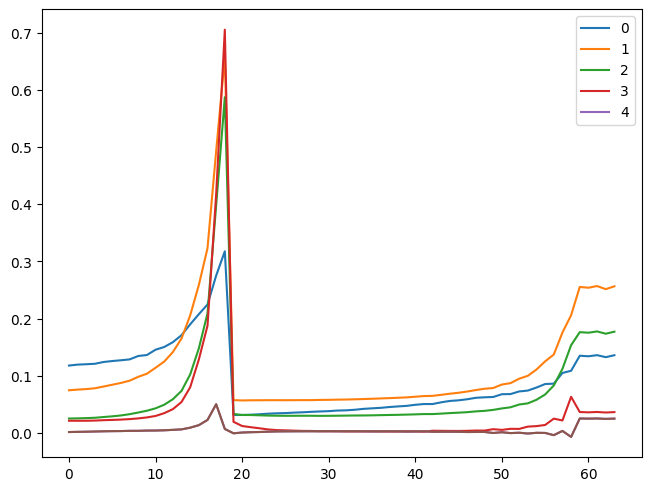

In [ ]:
for o in act_means: plt.plot(o)
plt.legend(range(5));

### Hook class

We can refactor this in a Hook class. It's very important to remove the hooks when they are deleted, otherwise there will be references kept and the memory won't be properly released when your model is deleted.

正常情况下，register_forward_hook返回值的销毁时机是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好问题！`register_forward_hook` 返回的是一个 `RemovableHandle` 对象。

这个 handle 的 `__del__` 方法里调用了 `remove()`，所以**理论上**当 handle 被垃圾回收时，hook 也会被自动移除。

但问题是：Python 的垃圾回收时机是不确定的。在有循环引用等情况下，GC 可能被延迟很久，甚至在一些特殊场景中永远不会触发。这就会导致：
- hook 一直挂在 module 上，每次 forward 都被调用
- 如果反复创建模型，内存可能泄露

所以最佳实践是**不要依赖 GC**，而是**显式管理**。这就是为什么 notebook 中说 "It's very important to remove the hooks when they are deleted"——通常的做法是：

1. **用上下文管理器**
2. **或者存下 handle，用完手动 `handle.remove()`**

想看看怎么封装成 `Hook` 类吗？还是继续往下走？

<details class='token-usage-details' markdown='1'><summary>$0.0003</summary>

`total=13,942 | in=13,177 | out=765 | cached=99.1% | reasoning=563 | searches=0 | $0.0003`

</details>


In [ ]:
#| export
class Hook():
    def __init__(self, m, f): self.hook = m.register_forward_hook(partial(f, self))
    def remove(self): self.hook.remove()
    def __del__(self): self.remove()

In [ ]:
def append_stats(hook, mod, inp, outp):
    if not hasattr(hook,'stats'): hook.stats = ([],[])
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean())
    hook.stats[1].append(acts.std())

传给append_stats的hook是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

问得好！我们拆开看这行：

```python
self.hook = m.register_forward_hook(partial(f, self))
```

这里 `partial(f, self)` 相当于把 `self`（也就是 `Hook` 实例）**固定为 `append_stats` 的第一个参数**。

所以当 PyTorch 触发这个 hook 时，实际调用的是：

```
append_stats(hook_instance, mod, inp, outp)
```

- `hook` → 就是 `Hook` 实例本身
- `mod` → 被 hook 挂载的那个 module（比如 `Conv2d` 或 `ReLU`）
- `inp` → module 的输入
- `outp` → module 的输出

聪明之处在于：把 `Hook` 实例传进去之后，hook 函数就可以**直接在 hook 对象上存储状态**（`hook.stats`），而不用依赖外部的全局列表了。这样每个 Hook 对象自己保管自己的统计数据，干净又独立。

<details class='token-usage-details' markdown='1'><summary>$0.0003</summary>

`total=14,088 | in=13,644 | out=444 | cached=96.6% | reasoning=231 | searches=0 | $0.0003`

</details>


In [ ]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

In [ ]:
type(model[:5])

torch.nn.modules.container.Sequential


In [ ]:
list(model[:5].children())

[Sequential(
   (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
   (1): ReLU()
 ),
 Sequential(
   (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
   (1): ReLU()
 ),
 Sequential(
   (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
   (1): ReLU()
 ),
 Sequential(
   (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
   (1): ReLU()
 ),
 Conv2d(64, 10, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))]


In [ ]:
hooks = [Hook(l, append_stats) for l in model[:5].children()]

model[:5].children()的.children用法，为什么不直接取model[:5]

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

好观察！实际上 `model[:5]` 和 `model[:5].children()` 在 Python 层面并不一样：

- `model[:5]` 是一个 `Sequential` 模块本身（容器）
- `model[:5].children()` 是容器里那 5 个**子模块**的迭代器

如果直接 `for l in model[:5]`，由于 `Sequential` 实现了 `__iter__`，它也**会**遍历出子模块，结果确实一样。

但用 `.children()` 更**显式**——读代码的人一眼就知道"我要的是每个子模块，不是这个容器"。不影响功能，但意图更清楚。

有点类似问"为什么用 `for item in list` 而不是 `for i in range(len(list))`"——结果一样，但前者更直接表达了意图。

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=15,159 | in=14,386 | out=773 | cached=95.2% | reasoning=592 | searches=0 | $0.0005`

</details>


In [ ]:
learn = fit(model)

accuracy,loss,epoch,train
0.159,2.299,0,train
0.199,2.099,0,eval


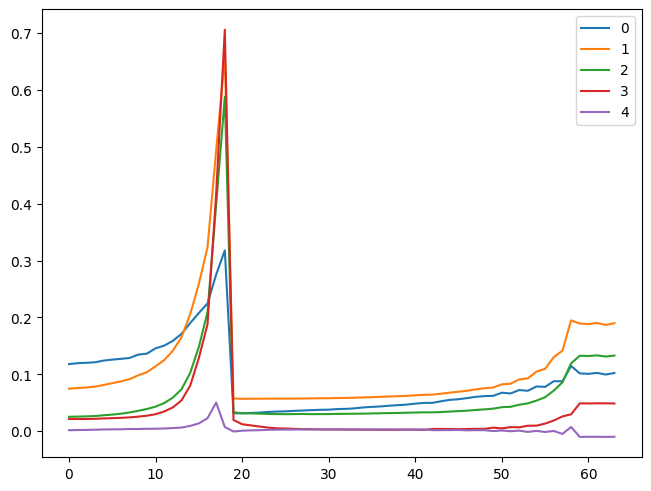

In [ ]:
for h in hooks:
    plt.plot(h.stats[0])
    h.remove()
plt.legend(range(5));

### A Hooks class

In [ ]:
class DummyCtxMgr:
    def __enter__(self, *args):
        print("let's go!")
        return self
    def __exit__ (self, *args): print("all done!")
    def hello(self): print("hello.")

In [ ]:
with DummyCtxMgr() as dcm: dcm.hello()

let's go!
hello.
all done!


In [ ]:
class DummyList(list):
    def __delitem__(self, i):
        print(f"Say bye to item {i}")
        super().__delitem__(i)

In [ ]:
dml = DummyList([1,3,2])
dml

[1, 3, 2]


In [ ]:
del(dml[2])
dml

Say bye to item 2


[1, 3]


In [ ]:
#| export
class Hooks(list):
    def __init__(self, ms, f): super().__init__([Hook(m, f) for m in ms])
    def __enter__(self, *args): return self
    def __exit__ (self, *args): self.remove()
    def __del__(self): self.remove()
    def __delitem__(self, i):
        self[i].remove()
        super().__delitem__(i)
    def remove(self):
        for h in self: h.remove()

In [ ]:
set_seed(1)
model = nn.Sequential(*cnn_layers())

accuracy,loss,epoch,train
0.159,2.299,0,train
0.198,2.094,0,eval


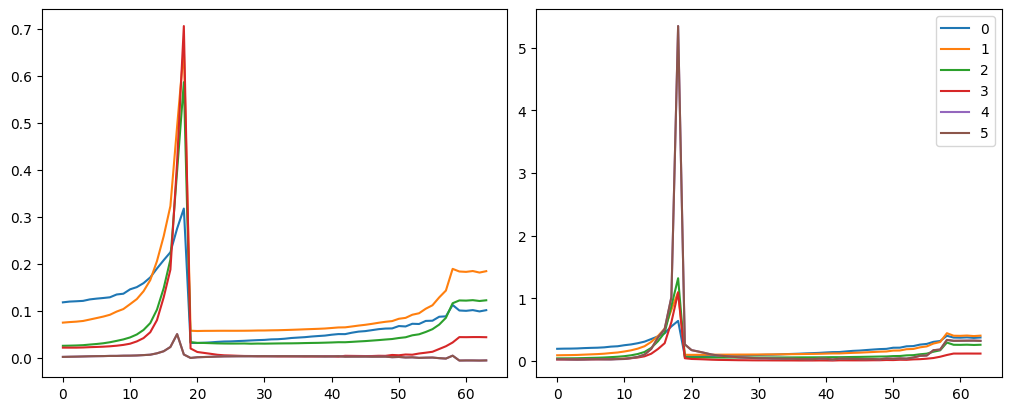

In [ ]:
with Hooks(model, append_stats) as hooks:
    fit(model)
    fig,axs = plt.subplots(1,2, figsize=(10,4))
    for h in hooks:
        for i in 0,1: axs[i].plot(h.stats[i])
    plt.legend(range(6));

### HooksCallback

In [ ]:
import inspect

print(inspect.getsource(fc.noop))

def noop (x=None, *args, **kwargs):
    "Do nothing"
    return x



In [ ]:
#| export
class HooksCallback(Callback):
    def __init__(self, hookfunc, mod_filter=fc.noop, on_train=True, on_valid=False, mods=None):
        fc.store_attr()
        super().__init__()
    
    def before_fit(self, learn):
        if self.mods: mods=self.mods
        else: mods = fc.filter_ex(learn.model.modules(), self.mod_filter)
        self.hooks = Hooks(mods, partial(self._hookfunc, learn))

    def _hookfunc(self, learn, *args, **kwargs):
        if (self.on_train and learn.training) or (self.on_valid and not learn.training): self.hookfunc(*args, **kwargs)

    def after_fit(self, learn): self.hooks.remove()
    def __iter__(self): return iter(self.hooks)
    def __len__(self): return len(self.hooks)

HooksCallback的作用是什么

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`HooksCallback` 把 hook 的创建和清理**自动化**了，整合到 `Learner` 的训练流程里：

1. **`before_fit`** — 训练开始前，自动在模型模块上挂 hook（可以用 `mod_filter` 过滤哪些层要 hook）
2. **`_hookfunc`** — 在 hook 回调里判断当前是训练还是验证阶段（`on_train` / `on_valid`），只在想要的阶段记录数据
3. **`after_fit`** — 训练结束后，自动 `remove()` 所有 hook，防止内存泄露

这样你就不用手动管理 hook 的生命周期了：

```python
# 以前：手动创建、手动移除
hooks = [Hook(l, append_stats) for l in model[:5]]
fit(model)
for h in hooks: h.remove()

# 用 HooksCallback：全自动
cb = HooksCallback(append_stats, mod_filter=lambda m: ...)
fit(model, xtra_cbs=[cb])
# 训练完 hook 自动被移除
```

它把"什么时候录、录哪些层、什么时候清理"打包成一个可插拔的 callback，很干净的设计。要继续看看 `mod_filter` 怎么用吗？

<details class='token-usage-details' markdown='1'><summary>$0.0005</summary>

`total=16,981 | in=16,169 | out=812 | cached=96.6% | reasoning=546 | searches=0 | $0.0005`

</details>


In [ ]:
hc = HooksCallback(append_stats, mod_filter=fc.risinstance(nn.Conv2d))

In [ ]:
set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[hc]);

accuracy,loss,epoch,train
0.158,2.300,0,train
0.199,2.104,0,eval


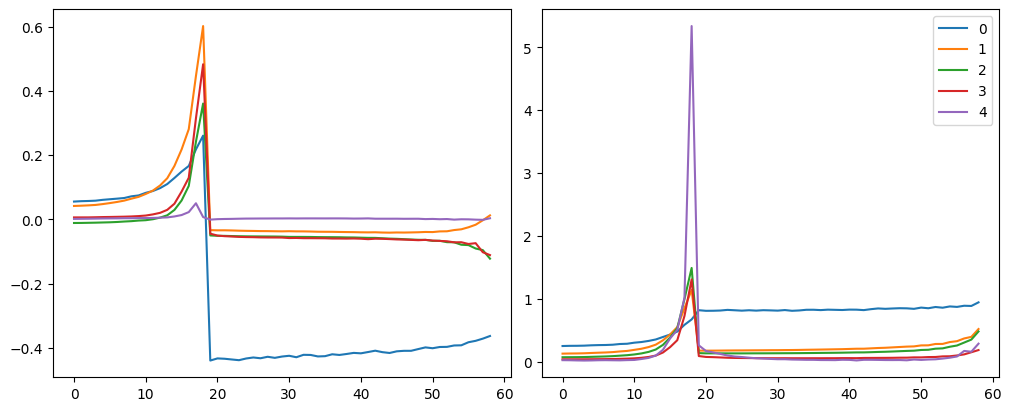

In [ ]:
fig,axs = plt.subplots(1,2, figsize=(10,4))
for h in hc:
    for i in 0,1: axs[i].plot(h.stats[i])
plt.legend(range(6));

## Histograms

In [ ]:
#| export
def append_stats(hook, mod, inp, outp):
    if not hasattr(hook,'stats'): hook.stats = ([],[],[])
    acts = to_cpu(outp)
    hook.stats[0].append(acts.mean())
    hook.stats[1].append(acts.std())
    hook.stats[2].append(acts.abs().histc(40,0,10))

accuracy,loss,epoch,train
0.156,2.298,0,train
0.278,2.048,0,eval


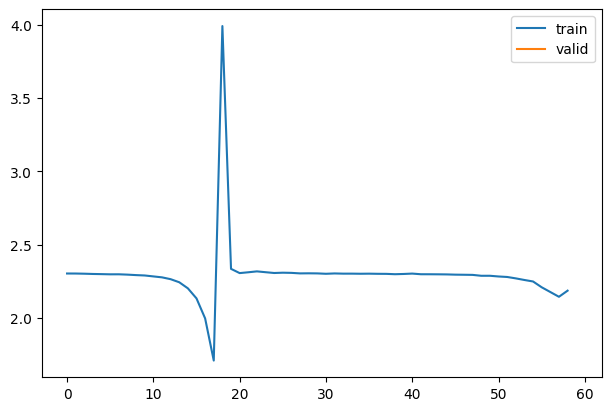

In [ ]:
set_seed(1)
model = nn.Sequential(*cnn_layers())
hc = HooksCallback(append_stats, mod_filter=fc.risinstance(nn.Conv2d))
fit(model, xtra_cbs=[hc]);

In [ ]:
#| export
# Thanks to @ste for initial version of histgram plotting code
def get_hist(h): return torch.stack(h.stats[2]).t().float().log1p()

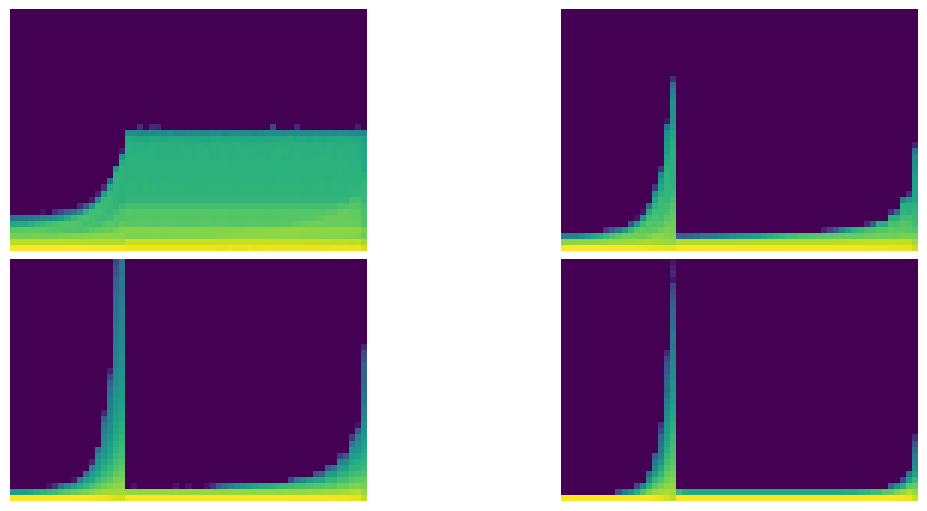

In [ ]:
fig,axes = get_grid(len(hc), figsize=(11,5))
for ax,h in zip(axes.flat, hc):
    show_image(get_hist(h), ax, origin='lower')

In [ ]:
#| export
def get_min(h):
    h1 = torch.stack(h.stats[2]).t().float()
    return h1[0]/h1.sum(0)

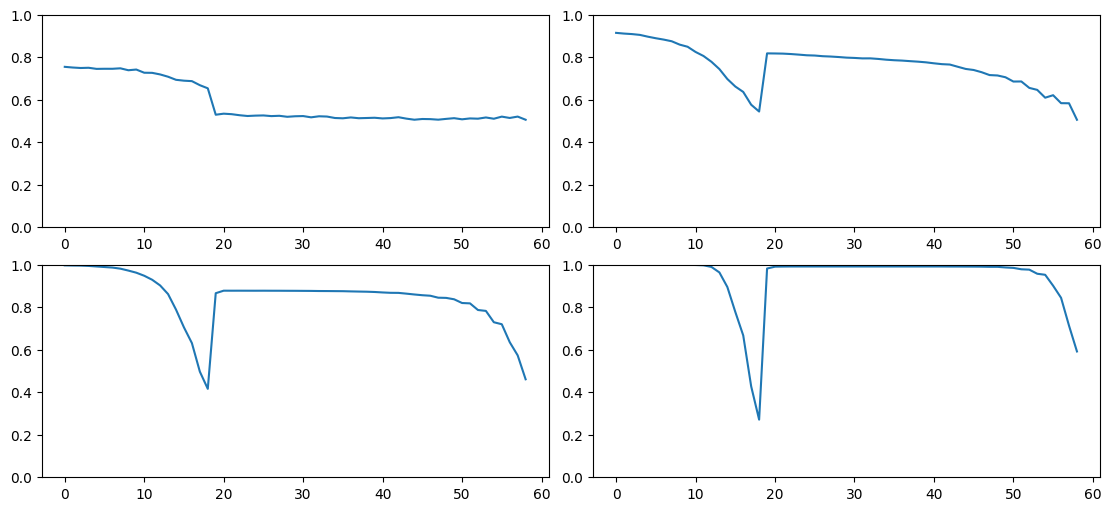

In [ ]:
fig,axes = get_grid(len(hc), figsize=(11,5))
for ax,h in zip(axes.flatten(), hc):
    ax.plot(get_min(h))
    ax.set_ylim(0,1)

## ActivationStats

In [ ]:
#|export
class ActivationStats(HooksCallback):
    def __init__(self, mod_filter=fc.noop): super().__init__(append_stats, mod_filter)

    def color_dim(self, figsize=(11,5)):
        fig,axes = get_grid(len(self), figsize=figsize)
        for ax,h in zip(axes.flat, self):
            show_image(get_hist(h), ax, origin='lower')

    def dead_chart(self, figsize=(11,5)):
        fig,axes = get_grid(len(self), figsize=figsize)
        for ax,h in zip(axes.flatten(), self):
            ax.plot(get_min(h))
            ax.set_ylim(0,1)

    def plot_stats(self, figsize=(10,4)):
        fig,axs = plt.subplots(1,2, figsize=figsize)
        for h in self:
            for i in 0,1: axs[i].plot(h.stats[i])
        axs[0].set_title('Means')
        axs[1].set_title('Stdevs')
        plt.legend(fc.L.range(self))

In [ ]:
astats = ActivationStats(fc.risinstance(nn.Conv2d))

accuracy,loss,epoch,train
0.156,2.298,0,train
0.278,2.048,0,eval


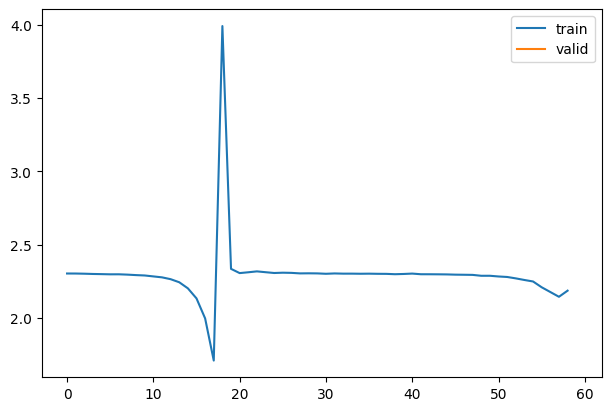

In [ ]:
set_seed(1)
model = nn.Sequential(*cnn_layers())
fit(model, xtra_cbs=[astats]);

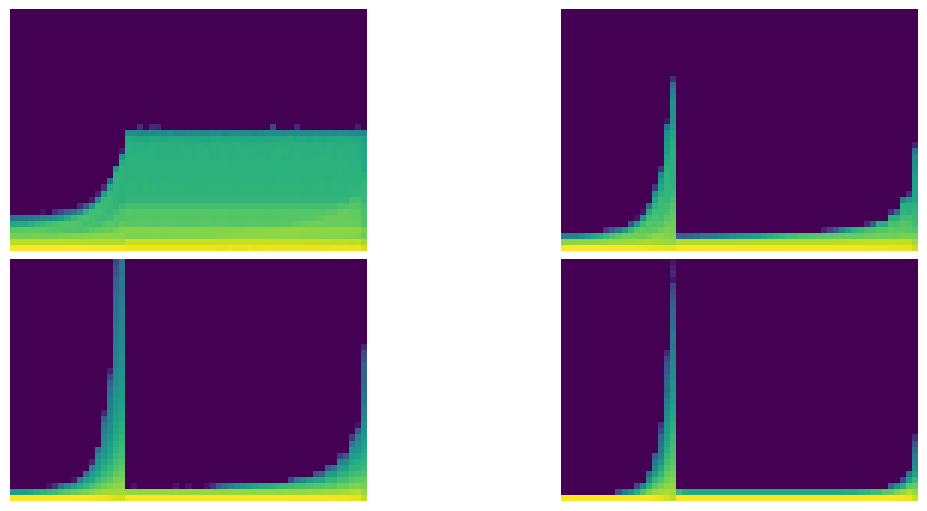

In [ ]:
astats.color_dim()

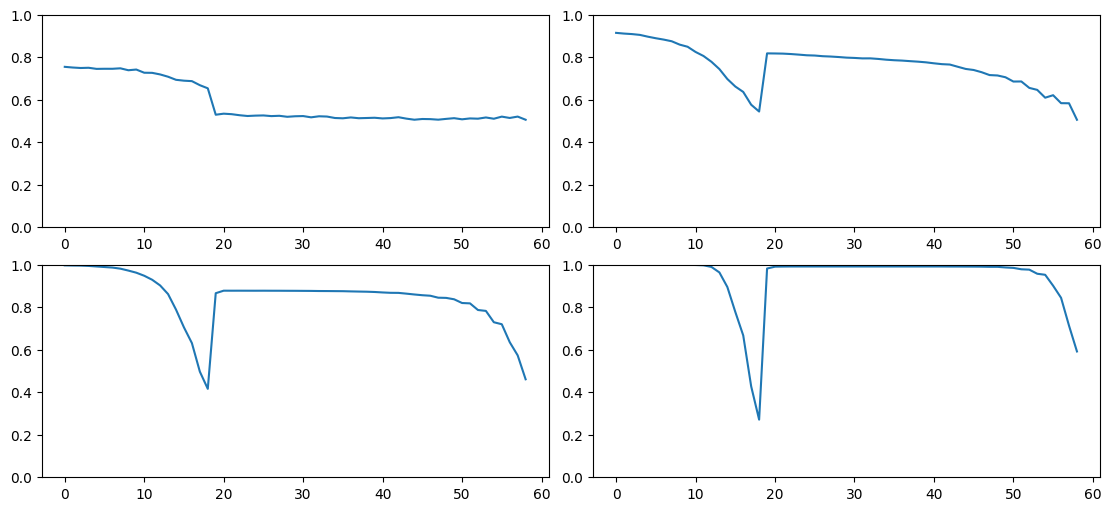

In [ ]:
astats.dead_chart()

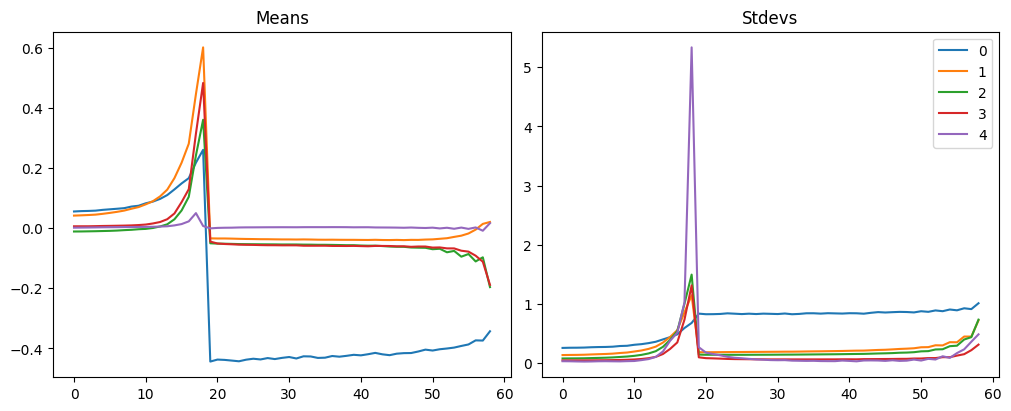

In [ ]:
astats.plot_stats()

## Export -

In [ ]:
import nbdev; nbdev.nbdev_export()